# 4. What must sit beside the front-page number so a director reads it right in two minutes?

**Week 2, Friday. Chapter 4 of 6.** Chapter 2 tied the quarters to the warehouse: Rs 10.00 crore in Q1
and Rs 9.84 crore in Q2, down 1.6 percent; in rupees Business carries Rs 14.30 lakh of the Rs 16.00
lakh fall, and the steepest fall is Retail-Plus, down 29.4 percent. Chapter 3 built the protect list.
The chief of staff's third ask is one number on the front page with its trend, and the number is
revenue, Q2 against Q1. Which metric belongs on a growth review's front page at all is a question for a
later week; this chapter is about making the one asked for impossible to misread.

> **The client asks.** "Monday's growth review deck needs three things I can open on my laptop
> without a login: the revenue tree by segment for both quarters, the top-fifty protect list with a
> lookup so I can find any member by id, and one number on the front page with its trend. Nothing
> that needs Python. If a director changes an assumption in the room, the sheet must recalculate in
> front of them."
>
> Meera's chief of staff, Kalpa Retail

**Who needs the answer.** Meera and the directors read the front page first and may read nothing else;
the chief of staff presents it and answers for it. A card without its period reads two quarters as one,
and a percentage without its base turns a Rs 1.72 lakh fall into a crisis the meeting spends its time
on.

**The questions on the way.**
1. What does a director read in a card that says "Revenue Rs 19.84 crore"?
2. Which form should the card take?
3. What does the card say with its period, comparison and base?
4. What does "Retail-Plus revenue down 29.4 percent" leave out?
5. What does the trend beside the number show, and what happens when a director changes the scope?
6. Does the warehouse reach the same change by its own route?

**The metric at stake.** Q2 revenue against Q1, booked order value in rupees, with Q1 April to June
2026 and Q2 July to September 2026.

**Who else faces it.** Every listed company writes this card each quarter. DMart's owner, Avenue
Supermarts, headlined its results for the quarter to 30 June 2025 as "Standalone Total Revenue up by
16.2% at Rs.15,932 Crore", and its release adds that revenue "stood at Rs.15,932 crore, as compared to
Rs.13,712 crore in the same period last year" (Avenue Supermarts press release, 11 July 2025, checked 30
September 2026). The number, its period, its comparison and its base are all in the first two lines.

**Setup.** The cell loads the raw export, adds Kalpa's quarter, counts each order once the way chapter 2
did, and defines `card()`, which writes the front-page card for a scope. It also defines `warehouse()`
for the second route.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv
import pandas as pd

DATA = kit.data_dir()
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


def money(n):
    """Rupees the way Kalpa's finance team reads them: crore, lakh, or rupees in full."""
    sign, a = ("-" if n < 0 else ""), abs(n)
    return sign + (crore(a) if a >= 1e7 else lakh(a) if a >= 1e5 else kit.rupees(round(a)))


def change(before, after):
    """The change from before to after, measured on before, in percent."""
    return (after - before) / before * 100

raw = pd.read_csv(DATA / "C2_W02_D05_raw_export_STUDENT.csv", keep_default_na=False)
raw["quarter"] = raw["order_date"].str[5:7].astype(int).map(lambda m: "Q1" if m <= 6 else "Q2")


def warehouse(query):
    """Ask the Kalpa warehouse itself, the source of truth every sheet ties back to."""
    return [{k: (int(v) if hasattr(v, "as_integer_ratio") and not isinstance(v, float) else v)
             for k, v in row.items()} for row in kit.sql(query)]

raw["first_row"] = (raw.groupby("order_id").cumcount() == 0).astype(int)   # =IF(COUNTIF($A$2:A2,A2)=1,1,0)
orders = raw[raw["first_row"] == 1]                                      # one row per order

seg_q = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum").reindex(SEGMENTS)
SCOPES = {"All segments": SEGMENTS, "All except Business": ["Retail-Core", "Retail-Plus", "Student"],
          "Retail-Plus": ["Retail-Plus"]}


def card(scope):
    """The front-page card for a scope: the number, its period, its comparison and its base."""
    q1, q2 = int(seg_q.loc[SCOPES[scope], "Q1"].sum()), int(seg_q.loc[SCOPES[scope], "Q2"].sum())
    share = q2 / int(seg_q["Q2"].sum()) * 100
    words = "down" if q2 < q1 else "up"
    return {"scope": scope, "Q1": q1, "Q2": q2, "change": change(q1, q2), "share": share,
            "sentence": f"{scope}, Q2, July to September 2026: {money(q2)}, {words} {abs(change(q1, q2)):.1f} percent "
                        f"on Q1, April to June 2026 ({money(q1)}); {share:.1f} percent of company revenue in Q2."}

print(f"{len(orders):,} orders, each counted once, from {len(raw):,} export rows")

1,000 orders, each counted once, from 1,450 export rows


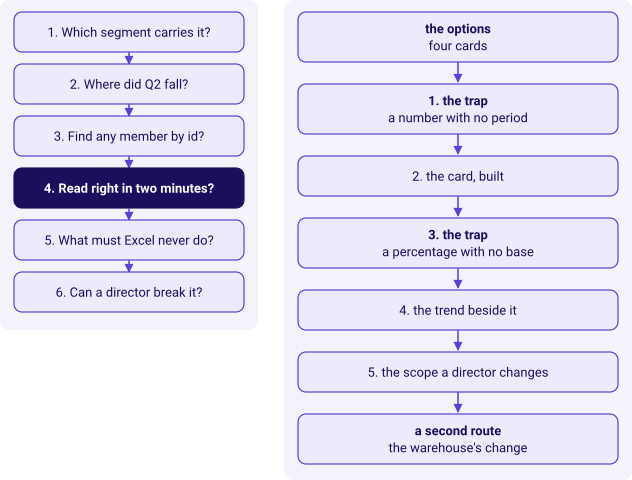

In [2]:
kit.side_by_side(
    kit.ladder(['Which segment carries it?', 'Where did Q2 fall?', 'Find any member by id?', 'Read right in two minutes?', 'What must Excel never do?', 'Can a director break it?'], lit=3, show=False),
    kit.vflow(['the options\nfour cards', '1. the trap\na number with no period', '2. the card, built', '3. the trap\na percentage with no base', '4. the trend beside it', '5. the scope a director changes', "a second route\nthe warehouse's change"], show=False),
)

## Which form should the front-page card take, and what does each ask the director to remember?

| Option | The card | What the director must bring to read it right |
|---|---|---|
| a) The total | "Revenue Rs 19.84 crore" | That it covers two quarters, and what the last figure was |
| b) The quarter | "Q2 revenue Rs 9.84 crore" | Q1's figure, from memory |
| c) The quarter against the last | "Q2, July to September 2026: Rs 9.84 crore, down 1.6 percent on Q1 (Rs 10.00 crore)" | Nothing |
| d) c, with its sentence and its trend | c, plus where the change sits and six months drawn as a line | Nothing, and it answers the next question too |

option,words on the card,what a director must bring
a) the total,4,"two facts: the period, and the last figure"
b) the quarter,5,one fact: Q1's figure
c) against the last,29,nothing
d) with sentence and trend,53,nothing


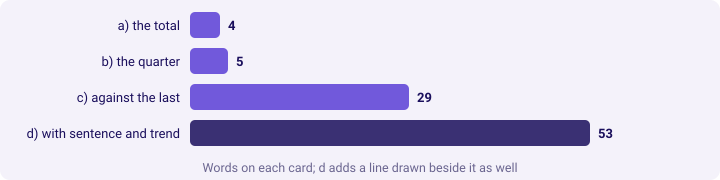

In [3]:
SENTENCE = ("Business invoices carry Rs 14.30 lakh of the Rs 16.00 lakh fall; Retail-Plus, the paid tier, "
            "fell 29.4 percent because members ordered less often.")
cards = {"a) the total": "Revenue Rs 19.84 crore",
         "b) the quarter": "Q2 revenue Rs 9.84 crore",
         "c) against the last": card("All segments")["sentence"],
         "d) with sentence and trend": card("All segments")["sentence"] + " " + SENTENCE}
remember = ["two facts: the period, and the last figure", "one fact: Q1's figure", "nothing", "nothing"]
kit.table(["option", "words on the card", "what a director must bring"],
          [(k, len(v.split()), m) for (k, v), m in zip(cards.items(), remember)], caption="Four cards, counted")
kit.bars([(k, len(v.split())) for k, v in cards.items()], lit=(3,),
         title="Words on each card; d adds a line drawn beside it as well")

**The best-fit call: d.** About fifty words and one small line chart, read in the two minutes a
director gives the front page, and nothing left to memory. **The fact that would change it:** a board that
reviews every month against the plan line, where the comparison on the card becomes the plan and not
the previous quarter.

## 1. What does a director read in a card that says "Revenue Rs 19.84 crore"?

The fastest card is the export's grand total in big type. It is correct: Rs 19.84 crore is Kalpa's
revenue for April to September.

**Predict before you run.** A director who remembers Q1 at Rs 10.00 crore reads this card as: a) two
quarters of revenue; b) revenue nearly doubled this quarter; c) a number to check later; d) nothing
wrong, since the number is right.

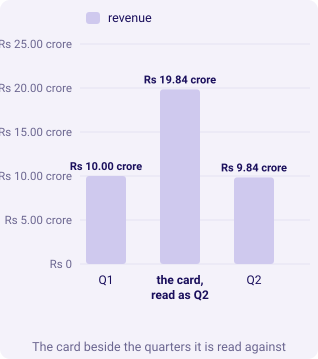

In [4]:
half_year = int(orders["order_amount"].sum())
read_as = change(100_000_000, half_year)
kit.stats([(crore(half_year), "the card", "April to September, two quarters"),
           (f"{read_as:+.1f}%", "what a director reads", "against Q1's remembered Rs 10.00 crore"),
           (crore(int(seg_q["Q2"].sum())), "Q2 alone", "the quarter the review is about")])
kit.columns(["Q1", "the card, read as Q2", "Q2"], [("revenue", [100_000_000, half_year, int(seg_q["Q2"].sum())])],
            fmt=money, lit=(1,), title="The card beside the quarters it is read against")
kit.check("the card's number is the two quarters added", half_year == int(seg_q["Q1"].sum() + seg_q["Q2"].sum()))

**What happened: the plausible wrong answer.** The answer is b. Read against Q1's Rs 10.00 crore, a
bare Rs 19.84 crore looks like revenue up 98.4 percent in a quarter when it fell 1.6 percent. The number
is right and its period is missing, so the reader supplies one. **Why it is wrong:** a director carries
that growth into the meeting's decisions, and the minutes record a boom that never happened. **The check
that catches it:** read the card aloud and ask which months, and against what; a card that cannot
answer is not ready. **The fix:** the period and the comparison on the card itself.

## 2. What does the card say with its period, comparison and base?

The card's change is measured on the earlier quarter: Q2 minus Q1, divided by Q1.

**Predict before you run.** The change on the card reads: a) down 1.6 percent; b) down 1.6 points; c) up
1.6 percent; d) down 16 percent.

In [5]:
company = card("All segments")
print(company["sentence"])
kit.stats([(money(company["Q2"]), "Q2, July to September 2026", "the number"),
           (f"{company['change']:+.1f}%", "on Q1", "the comparison"),
           (money(company["Q1"]), "Q1, April to June 2026", "the base")])
kit.check("the card's quarters add back to the half-year", company["Q1"] + company["Q2"] == half_year)
kit.check("the change is measured on Q1", abs(company["change"] - (company["Q2"] - company["Q1"]) / company["Q1"] * 100) < 1e-9)

All segments, Q2, July to September 2026: Rs 9.84 crore, down 1.6 percent on Q1, April to June 2026 (Rs 10.00 crore); 100.0 percent of company revenue in Q2.


**What happened.** The answer is a. The card reads: "All segments, Q2, July to September 2026: Rs 9.84
crore, down 1.6 percent on Q1, April to June 2026 (Rs 10.00 crore); 100.0 percent of company revenue
in Q2." The sentence beside it says where the change sits, and chapter 2 gave both halves: Business
invoices carry Rs 14.30 lakh of the Rs 16.00 lakh fall, and Retail-Plus, the paid tier, fell 29.4
percent because members ordered less often.

## 3. What does "Retail-Plus revenue down 29.4 percent" leave out?

The second slot on the front page is drafted as "Retail-Plus revenue down 29.4 percent". The
percentage is right.

**Predict before you run.** What must sit beside it? a) nothing, since it is correct; b) its rupee
base and its share of company revenue; c) the Business figure for comparison; d) the protect list.

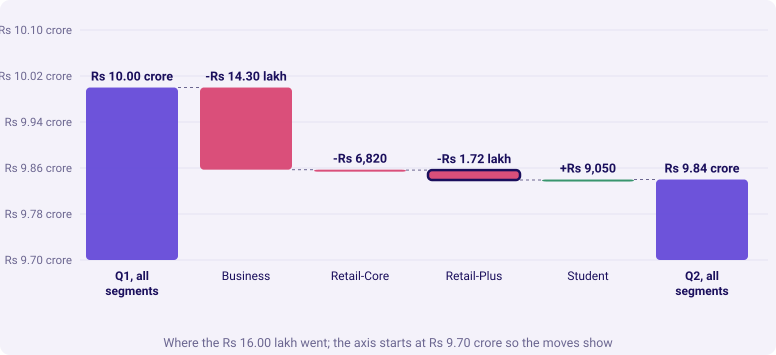

In [6]:
rp = card("Retail-Plus")
fall = rp["Q1"] - rp["Q2"]
wrong_base = (rp["Q2"] - rp["Q1"]) / rp["Q2"] * 100
kit.stats([(f"{rp['change']:+.1f}%", "Retail-Plus, as drafted", "no base, no share"),
           (lakh(fall), "the fall in rupees", "on a Rs 10.00 crore quarter"),
           (f"{rp['share']:.1f}%", "Retail-Plus's share of Q2", "the base the draft left out"),
           (f"{wrong_base:+.1f}%", "the same change divided by Q2", "the slip that makes it worse")])
kit.bridge(("Q1, all segments", company["Q1"]),
           [(s, int(seg_q.loc[s, "Q2"] - seg_q.loc[s, "Q1"])) for s in SEGMENTS],
           end_label="Q2, all segments", fmt=money, lit=(2,), lo=97_000_000,
           title="Where the Rs 16.00 lakh went; the axis starts at Rs 9.70 crore so the moves show")
kit.check("the drafted percentage is right on its own base", abs(rp["change"] + 29.43) < 0.01, f"{rp['change']:.2f} percent")
kit.check("Retail-Plus is under half a percent of Q2 revenue", rp["share"] < 0.5, f"{rp['share']:.2f} percent")

**What happened: the plausible wrong answer.** The answer is b. Read without its base, "down 29.4
percent" sounds like the business collapsing, and the meeting argues about a panic instead of about
members who order less often. It is 29.4 percent of Rs 5.86 lakh: a fall of Rs 1.72 lakh on a Rs 10.00
crore quarter, where Retail-Plus is 0.4 percent of revenue. A second slip makes it worse: divide the
same change by Q2 instead of Q1 and it reads 41.7 percent. **The check:** the rupee base and the share
beside every percentage, and the change divided by the earlier period. **The fix:** "Retail-Plus, Q2:
Rs 4.13 lakh, down 29.4 percent on Q1 (Rs 5.86 lakh); 0.4 percent of company revenue."

## 4. What does the trend beside the number show, and what happens when a director changes the scope?

The chief of staff asked for the number "with its trend". Six months of revenue, drawn as a line, for
the scope the card states. The scope is an input a director can change: all segments, all except
Business, or Retail-Plus alone.

**Predict before you run.** Taking Business out, the change on the card reads: a) down 1.6 percent; b)
down 17.3 percent; c) down 29.4 percent; d) up 33.9 percent.

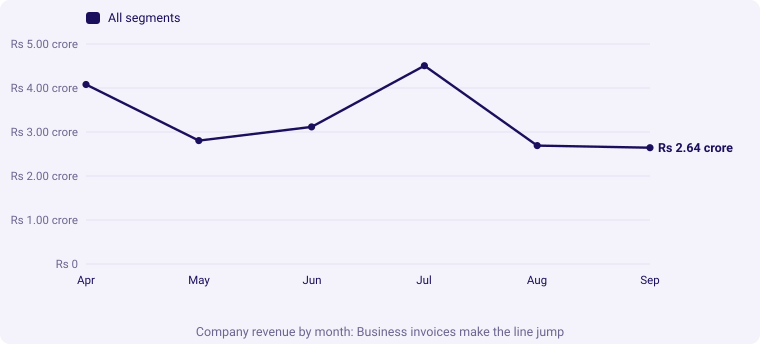

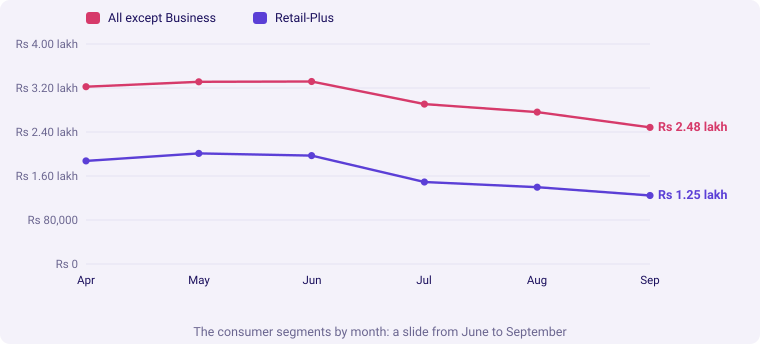

The director asks for,The card says
All segments,"All segments, Q2, July to September 2026: Rs 9.84 crore, down 1.6 percent on Q1, April to June 2026 (Rs 10.00 crore); 100.0 percent of company revenue in Q2."
All except Business,"All except Business, Q2, July to September 2026: Rs 8.15 lakh, down 17.3 percent on Q1, April to June 2026 (Rs 9.86 lakh); 0.8 percent of company revenue in Q2."
Retail-Plus,"Retail-Plus, Q2, July to September 2026: Rs 4.13 lakh, down 29.4 percent on Q1, April to June 2026 (Rs 5.86 lakh); 0.4 percent of company revenue in Q2."


In [7]:
orders["month"] = orders["order_date"].str[:7]
months = sorted(orders["month"].unique())
labels = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]
by_month = {scope: [int(orders[(orders["month"] == m) & orders["segment"].isin(segs)]["order_amount"].sum()) for m in months]
            for scope, segs in SCOPES.items()}
kit.line(labels, [("All segments", by_month["All segments"], "lit")], fmt=money,
         title="Company revenue by month: Business invoices make the line jump")
kit.line(labels, [("All except Business", by_month["All except Business"], "bad"),
                  ("Retail-Plus", by_month["Retail-Plus"], "")], fmt=money,
         title="The consumer segments by month: a slide from June to September")
kit.table(["The director asks for", "The card says"], [(s, card(s)["sentence"]) for s in SCOPES], caption="One input, three honest cards")
kit.check("July's company revenue sits above June's", by_month["All segments"][3] > by_month["All segments"][2])
kit.check("the consumer line ends lower than it stood in June", by_month["All except Business"][-1] < by_month["All except Business"][2])

**What happened.** The answer is b. Taking Business out, revenue fell from Rs 9.86 lakh to Rs 8.15 lakh,
down 17.3 percent, 0.8 percent of company revenue. The company line jumps in July to Rs 4.51 crore, 45
percent above June, because corporate invoices landed in it, and then falls; the consumer line slides
from Rs 3.32 lakh in June to Rs 2.48 lakh in September. Two directors asking for two scopes get two
honest cards, each saying which scope it shows, so down 1.6 percent and down 17.3 percent are never
compared as one number.

## A second route: does the warehouse reach the same change by its own query?

The card was computed from the export. The second route asks the warehouse's orders table, joined to
its customers for the segment, and asserts the same two changes.

In [8]:
wq = {r["quarter"]: r["revenue"] for r in warehouse("SELECT quarter, sum(amount) AS revenue FROM orders GROUP BY quarter")}
wp = {r["quarter"]: r["revenue"] for r in warehouse(
    "SELECT o.quarter, sum(o.amount) AS revenue FROM orders o JOIN customers c USING (customer_id) "
    "WHERE c.segment = 'Retail-Plus' GROUP BY o.quarter")}
kit.table(["Scope", "Card, from the export", "Warehouse"],
          [("All segments", f"{company['change']:+.2f}%", f"{change(wq['Q1'], wq['Q2']):+.2f}%"),
           ("Retail-Plus", f"{rp['change']:+.2f}%", f"{change(wp['Q1'], wp['Q2']):+.2f}%")])
kit.check("the company change matches the warehouse", abs(company["change"] - change(wq["Q1"], wq["Q2"])) < 1e-9)
kit.check("the Retail-Plus change matches the warehouse", abs(rp["change"] - change(wp["Q1"], wp["Q2"])) < 1e-9)

Scope,"Card, from the export",Warehouse
All segments,-1.60%,-1.60%
Retail-Plus,-29.43%,-29.43%


> **Kavya's review.** "A number without its period is read against whatever the director remembers. A
> percentage without its base is read as whatever the director fears. If the card cannot say which
> months, against what and out of how much, it goes back."

### In the interview: how would you answer these three questions aloud?

**[F] How do you present one number so it is not misread?** With its period, its comparison and its
base, and one sentence on what moved it. Here: Q2, July to September 2026, Rs 9.84 crore, down 1.6
percent on Q1's Rs 10.00 crore; Business invoices carry most of the rupees, and Retail-Plus fell 29.4
percent because members ordered less often.

**[F] A director says revenue doubled; your card says Rs 19.84 crore. What is missing?** The period. It
is two quarters added together, read against one quarter from memory; the card needs its months and its
comparison, and then it reads down 1.6 percent.

**[D] A segment fell 29 percent and is 0.4 percent of revenue. Does it go on the front page, and how?**
Only with its base and its share, and in the sentence beside the headline rather than as the headline:
Rs 4.13 lakh, down 29.4 percent on Rs 5.86 lakh, 0.4 percent of revenue. It matters because it is the
paid tier and the fall is in how often members buy; it is small in rupees, and the card says both.

### Depth: a percentage or percentage points?

A change in a rate is quoted in points, a change in an amount in percent. If the share of revenue from
the consumer segments moved from 0.99 percent in Q1 to 0.83 percent in Q2, it fell by 0.16 percentage
points, which is a 16 percent fall in the share. Both are true and they read very differently, so a
card that shows a share says which it means. The consumer shares here come from this notebook's own
quarters: Rs 9.86 lakh of Rs 10.00 crore, and Rs 8.15 lakh of Rs 9.84 crore.

## What did this chapter answer, one question at a time?

1. "Revenue Rs 19.84 crore" is two quarters, and a director who remembers Q1's Rs 10.00 crore reads it as up 98.4 percent.
2. Option d: the quarter against the last, with its base, its sentence and its trend.
3. "Q2, July to September 2026: Rs 9.84 crore, down 1.6 percent on Q1, April to June 2026 (Rs 10.00 crore)."
4. The base and the share: Rs 1.72 lakh on Rs 5.86 lakh, 0.4 percent of revenue; divided by Q2 by mistake it reads 41.7 percent.
5. The company line jumps in July on corporate invoices; without Business, revenue is down 17.3 percent, and each scope prints its own name.
6. The warehouse gives the same -1.6 percent and -29.4 percent.

The next question is chapter 5's: Kavya wants to know which of the week's steps may live in this workbook
at all.

In [9]:
kit.check_summary()